# Grammar Scoring Engine for Spoken Audio
**Goal:** predict a continuous MOS grammar score (0-5) from a 45-60 s speech clip.

**Approach (summary, full report at the end):**
1. **ASR** - Whisper transcribes each clip, so grammar can be judged on text.
2. **Text-grammar features** - CoLA grammatical-acceptability model, GPT-2 perplexity, syntax/fluency statistics, sentence embeddings.
3. **Acoustic features** - WavLM embeddings (mean+std pooled over several layers) capture fluency, hesitations and proficiency cues that ASR text loses.
4. **Models** - Ridge / SVR / Kernel Ridge / LightGBM per feature block, evaluated with repeated K-fold CV.
5. **Stacking** - non-negative linear meta-model on out-of-fold predictions, clipped to [0, 5].

Metric: **RMSE** (training RMSE is reported explicitly, as required, next to the cross-validated RMSE which is the honest estimate)

In [1]:
!pip -q install lightgbm sentence-transformers 2>/dev/null
import os, re, glob, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, librosa
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SR = 16000
CACHE = '/kaggle/working/cache'; os.makedirs(CACHE, exist_ok=True)

# ---- EDIT THIS to the competition folder name ----
DATA_DIR = glob.glob('/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final')[0]
print('Data dir:', DATA_DIR, '| device:', DEVICE)
print(os.listdir(DATA_DIR))

Data dir: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final | device: cuda
['sample_submission.csv', 'train.csv', 'test.csv', 'test', 'train']


In [2]:
train = pd.read_csv(f'{DATA_DIR}/train.csv'); test = pd.read_csv(f'{DATA_DIR}/test.csv')
sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')
print(train.head(), test.head(), sub.head(), sep='\n\n')

# Auto-detect column names (file-name column and label column)
FILE_COL = train.columns[0]
LABEL_COL = [c for c in train.columns if c != FILE_COL][0]
print('file col:', FILE_COL, '| label col:', LABEL_COL)

def find_audio(name, split):
    name = str(name)
    if not name.endswith('.wav'): name += '.wav'
    for p in [f'{DATA_DIR}/{split}/{name}', f'{DATA_DIR}/audios/{split}/{name}', f'{DATA_DIR}/audios_{split}/{name}', f'{DATA_DIR}/{name}']:
        if os.path.exists(p): return p
    hits = glob.glob(f'{DATA_DIR}/**/{name}', recursive=True)
    assert hits, f'Audio not found: {name}'
    return hits[0]

train['path'] = [find_audio(f, 'train') for f in train[FILE_COL]]
test['path']  = [find_audio(f, 'test')  for f in test[FILE_COL]]
y = train[LABEL_COL].values.astype(float)

        filename  label
0  audio_192.wav    3.0
1  audio_436.wav    3.0
2  audio_447.wav    3.5
3  audio_126.wav    2.0
4   audio_61.wav    2.0

        filename  label
0  audio_128.wav     -1
1  audio_156.wav     -1
2   audio_19.wav     -1
3  audio_108.wav     -1
4  audio_206.wav     -1

         filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
3   audio_774.wav     -1
4  audio_1138.wav     -1
file col: filename | label col: label


## 1. Exploratory analysis

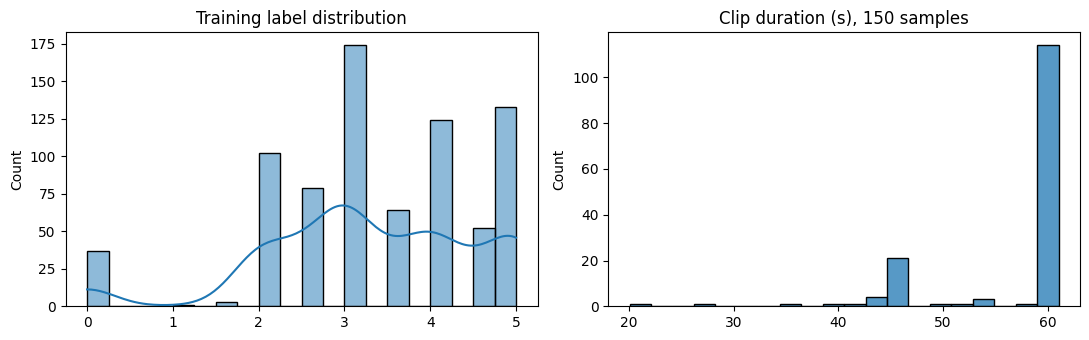

count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
dtype: float64


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(y, bins=20, kde=True, ax=ax[0]); ax[0].set_title('Training label distribution')
dur = [librosa.get_duration(path=p) for p in train['path'][:150]]
sns.histplot(dur, bins=20, ax=ax[1]); ax[1].set_title('Clip duration (s), 150 samples')
plt.tight_layout(); plt.show()
print(pd.Series(y).describe())

## 2. Load audio (16 kHz mono)

In [4]:
def load_audio(p):
    w, _ = librosa.load(p, sr=SR, mono=True)
    w, _ = librosa.effects.trim(w, top_db=35)          # trim leading/trailing silence
    return w.astype(np.float32)

all_df = pd.concat([train.assign(split='train'), test.assign(split='test')], ignore_index=True)
waves = [load_audio(p) for p in tqdm(all_df['path'])]
ntr = len(train)

  0%|          | 0/985 [00:00<?, ?it/s]

## 3. ASR with Whisper
Whisper normalises many disfluencies, so we also keep its confidence (avg log-prob), which correlates with intelligibility/fluency.

In [5]:
from transformers import pipeline

ASR_MODEL = (
    'openai/whisper-medium.en'
    if DEVICE == 'cuda'
    else 'openai/whisper-small.en'
)

f_tx = f'{CACHE}/transcripts.csv'

if os.path.exists(f_tx):
    all_df['text'] = pd.read_csv(f_tx)['text'].fillna('').values
else:
    asr = pipeline(
        'automatic-speech-recognition',
        model=ASR_MODEL,
        device=0 if DEVICE == 'cuda' else -1,
        torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
        chunk_length_s=30,
        batch_size=8 if DEVICE == 'cuda' else 1
    )

    texts = []

    for i in tqdm(range(0, len(waves), 8)):
        batch = [
            {'raw': w, 'sampling_rate': SR}
            for w in waves[i:i+8]
        ]

        # No language/task for .en models
        out = asr(batch)

        texts += [o['text'].strip() for o in out]

    all_df['text'] = texts
    all_df[['text']].to_csv(f_tx, index=False)

    del asr
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

for t, s in zip(all_df['text'][:3], y[:3]):
    print(f'[score {s}]', t[:300], '\n')

config.json:   0%|          | 0.00/1.95k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.06GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


  0%|          | 0/124 [00:00<?, ?it/s]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[score 3.0] The playground is very, very beautiful and fun. There are playthings like the miracle round, the swing. The students usually enjoy the swing. It has to be like, it's more like a game of pay because one sits in it and the other will have to push and the male goes around and climbs on it. Most of them 

[score 3.0] The scene of a school playground. Our playground looks like a very big playground having more greenery trees. In which way students like to garden more trees to have a fresh air and having a fresh oxygen. In the playground these trees gives a very greenery view which is very pleasant to our minds an 

[score 3.5] My favorite place to visit is the beach. I love the sound of the waves crashing against the shore, the feeling of the sand between my toys and the smell of the salt water. I love the fact that there is always something to do at the beach. I can swim, sun bath, build sand castle or just relax and lis 



## 4. Text / grammar features
- **Handcrafted:** word count, speech rate, sentence length, type-token ratio, repetitions, filler words, contractions, subordination markers, POS-diversity proxies.
- **CoLA acceptability** (`textattack/roberta-base-CoLA`): per-sentence probability of being grammatical -> mean/min/std/fraction>0.5.
- **GPT-2 perplexity:** ungrammatical text has higher per-token loss.
- **Sentence embedding** (`all-mpnet-base-v2`).

In [6]:
FILLERS = r'\b(um+|uh+|er+|ah+|hmm+|like|you know|i mean|kind of|sort of)\b'
SUBORD  = r'\b(because|although|though|while|whereas|which|who|whom|whose|that|if|unless|when|since|after|before|however|therefore|moreover)\b'

def split_sents(t):
    s = [x.strip() for x in re.split(r'(?<=[.!?])\s+', t) if len(x.strip().split()) > 1]
    return s if s else [t if t else 'empty']

def handcrafted(t, dur):
    words = re.findall(r"[A-Za-z']+", t.lower()); n = max(len(words), 1)
    sents = split_sents(t); sl = [len(s.split()) for s in sents]
    rep = sum(1 for a, b in zip(words, words[1:]) if a == b)
    return dict(n_words=n, wps=n/max(dur,1), n_sents=len(sents), avg_sl=np.mean(sl), max_sl=np.max(sl), std_sl=np.std(sl),
                ttr=len(set(words))/n, uniq=len(set(words)), avg_wlen=np.mean([len(w) for w in words]) if words else 0,
                rep=rep, fillers=len(re.findall(FILLERS, t.lower()))/n, subord=len(re.findall(SUBORD, t.lower()))/n,
                contr=t.count("'")/n, commas=t.count(',')/n, long_words=np.mean([len(w)>6 for w in words]) if words else 0)

durs = np.array([len(w)/SR for w in waves])
HC = pd.DataFrame([handcrafted(t, d) for t, d in zip(all_df['text'], durs)])
HC['dur'] = durs
print(HC.shape)

(985, 16)


In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
f_cola = f'{CACHE}/cola.npy'; f_ppl = f'{CACHE}/ppl.npy'

# ---- CoLA ----
if not os.path.exists(f_cola):
    tok = AutoTokenizer.from_pretrained('textattack/roberta-base-CoLA')
    m = AutoModelForSequenceClassification.from_pretrained('textattack/roberta-base-CoLA').to(DEVICE).eval()
    feats = []
    for t in tqdm(all_df['text']):
        s = split_sents(t)
        with torch.no_grad():
            enc = tok(s, return_tensors='pt', padding=True, truncation=True, max_length=128).to(DEVICE)
            p = torch.softmax(m(**enc).logits, -1)[:, 1].cpu().numpy()   # P(acceptable); check label order below
        feats.append([p.mean(), p.min(), p.max(), p.std(), (p > .5).mean(), np.median(p)])
    np.save(f_cola, np.array(feats)); del m; torch.cuda.empty_cache()
COLA = np.load(f_cola)
print('CoLA mean-prob vs label corr:', np.corrcoef(COLA[:ntr, 0], y)[0, 1])   # if strongly negative, label order is flipped - harmless for regression

# ---- GPT-2 perplexity ----
if not os.path.exists(f_ppl):
    tok = AutoTokenizer.from_pretrained('gpt2-medium'); lm = AutoModelForCausalLM.from_pretrained('gpt2-medium').to(DEVICE).eval()
    feats = []
    for t in tqdm(all_df['text']):
        s = split_sents(t); losses = []
        for x in s:
            ids = tok(x, return_tensors='pt', truncation=True, max_length=128).input_ids.to(DEVICE)
            if ids.shape[1] < 2: continue
            with torch.no_grad(): losses.append(lm(ids, labels=ids).loss.item())
        losses = losses or [10.]
        feats.append([np.mean(losses), np.max(losses), np.std(losses), np.percentile(losses, 75)])
    np.save(f_ppl, np.array(feats)); del lm; torch.cuda.empty_cache()
PPL = np.load(f_ppl)
print('GPT2 loss vs label corr:', np.corrcoef(PPL[:ntr, 0], y)[0, 1])

config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

  0%|          | 0/985 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


GPT2 loss vs label corr: -0.2648103113201979


In [8]:
from sentence_transformers import SentenceTransformer
f_emb = f'{CACHE}/sbert.npy'
if not os.path.exists(f_emb):
    st = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=DEVICE)
    np.save(f_emb, st.encode(all_df['text'].tolist(), batch_size=32, show_progress_bar=True)); del st
SBERT = np.load(f_emb)

TXT = np.hstack([HC.values, COLA, PPL])          # compact, interpretable text-grammar block
TXT_NAMES = list(HC.columns) + ['cola_mean','cola_min','cola_max','cola_std','cola_frac','cola_med'] + ['ppl_mean','ppl_max','ppl_std','ppl_p75']

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

## 5. Acoustic embeddings (WavLM)
Mean + std pooling over time for a few transformer layers (middle layers carry the most linguistic/prosodic info).

In [9]:
from transformers import AutoFeatureExtractor, AutoModel
f_ac = f'{CACHE}/wavlm.npy'
if not os.path.exists(f_ac):
    fe = AutoFeatureExtractor.from_pretrained('microsoft/wavlm-base-plus')
    wm = AutoModel.from_pretrained('microsoft/wavlm-base-plus').to(DEVICE).eval()
    LAYERS = [4, 6, 8, 10, 12]; feats = []
    for w in tqdm(waves):
        w = w[:SR*60]
        x = fe(w, sampling_rate=SR, return_tensors='pt').input_values.to(DEVICE)
        with torch.no_grad(): hs = wm(x, output_hidden_states=True).hidden_states
        v = [torch.cat([hs[l][0].mean(0), hs[l][0].std(0)]) for l in LAYERS]
        feats.append(torch.cat(v).cpu().numpy())
    np.save(f_ac, np.array(feats)); del wm; torch.cuda.empty_cache()
ACOU = np.load(f_ac); print(ACOU.shape)

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

  0%|          | 0/985 [00:00<?, ?it/s]

(985, 7680)


## 6. Modelling: per-block base models -> stacking
Repeated 5-fold CV produces **out-of-fold (OOF)** predictions; a non-negative linear meta-learner combines them.

In [10]:
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

rmse = lambda a, b: float(np.sqrt(mean_squared_error(a, b)))
blocks = {'txt': TXT, 'sbert': SBERT, 'acou': ACOU, 'all': np.hstack([TXT, SBERT, ACOU])}
alphas = np.logspace(-1, 4, 20)

def make_models(name):
    m = {f'ridge_{name}': make_pipeline(StandardScaler(), RidgeCV(alphas=alphas)),
         f'svr_{name}':   make_pipeline(StandardScaler(), SVR(C=2.0, epsilon=0.1, gamma='scale'))}
    if name in ('acou', 'all'):
        m[f'svr_{name}'] = make_pipeline(StandardScaler(), PCA(0.95, random_state=SEED), SVR(C=2.0, epsilon=0.1, gamma='scale'))
    if name in ('txt', 'all'):
        m[f'lgb_{name}'] = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=8, subsample=0.8, subsample_freq=1,
                                             colsample_bytree=0.5, min_child_samples=10, reg_lambda=2, random_state=SEED, verbose=-1)
    return m

base = {}
for b in blocks: base.update({k: (v, b) for k, v in make_models(b).items()})

N_REPEATS, N_SPLITS = 3, 5
oof = {k: np.zeros((N_REPEATS, ntr)) for k in base}
for r in range(N_REPEATS):
    for tr, va in KFold(N_SPLITS, shuffle=True, random_state=SEED + r).split(np.arange(ntr)):
        for k, (mdl, b) in base.items():
            from sklearn.base import clone
            m = clone(mdl).fit(blocks[b][:ntr][tr], y[tr])
            oof[k][r, va] = m.predict(blocks[b][:ntr][va])
OOF = {k: v.mean(0) for k, v in oof.items()}
res = pd.DataFrame({'model': list(OOF), 'CV_RMSE': [rmse(y, np.clip(p, 0, 5)) for p in OOF.values()]}).sort_values('CV_RMSE')
print(res.to_string(index=False)); print('Baseline (predict mean) RMSE:', rmse(y, np.full_like(y, y.mean())))

      model  CV_RMSE
  ridge_all 0.527081
 ridge_acou 0.535866
    svr_all 0.538000
    lgb_all 0.549817
   svr_acou 0.551056
    lgb_txt 0.895450
  ridge_txt 0.935627
    svr_txt 0.948658
ridge_sbert 1.028210
  svr_sbert 1.045410
Baseline (predict mean) RMSE: 1.2381936808002134


In [11]:
# Meta-learner: non-negative linear stacking on OOF predictions
keys = list(OOF); P = np.column_stack([OOF[k] for k in keys])
meta = LinearRegression(positive=True).fit(P, y)
print(dict(zip(keys, np.round(meta.coef_, 3))), 'intercept', round(meta.intercept_, 3))

# Honest stacking estimate: CV over the OOF matrix
st_oof = np.zeros(ntr)
for tr, va in KFold(5, shuffle=True, random_state=0).split(P):
    st_oof[va] = LinearRegression(positive=True).fit(P[tr], y[tr]).predict(P[va])
st_oof = np.clip(st_oof, 0, 5)
CV_RMSE = rmse(y, st_oof)
print(f'Stacked CV RMSE (honest estimate): {CV_RMSE:.4f} | Pearson r: {np.corrcoef(y, st_oof)[0,1]:.4f}')

{'ridge_txt': np.float64(0.07), 'svr_txt': np.float64(0.081), 'lgb_txt': np.float64(0.0), 'ridge_sbert': np.float64(0.035), 'svr_sbert': np.float64(0.009), 'ridge_acou': np.float64(0.416), 'svr_acou': np.float64(0.0), 'ridge_all': np.float64(0.085), 'svr_all': np.float64(0.189), 'lgb_all': np.float64(0.242)} intercept -0.443
Stacked CV RMSE (honest estimate): 0.5139 | Pearson r: 0.9100


## 7. Final fit on all training data + REQUIRED training RMSE

In [12]:
final = {k: clone(mdl).fit(blocks[b][:ntr], y) for k, (mdl, b) in base.items()}
tr_P = np.column_stack([final[k].predict(blocks[base[k][1]][:ntr]) for k in keys])
train_pred = np.clip(meta.predict(tr_P), 0, 5)
TRAIN_RMSE = rmse(y, train_pred)
print('='*50); print(f'TRAINING RMSE (in-sample)      : {TRAIN_RMSE:.4f}'); print(f'CROSS-VALIDATED RMSE (held-out): {CV_RMSE:.4f}'); print('='*50)

TRAINING RMSE (in-sample)      : 0.1891
CROSS-VALIDATED RMSE (held-out): 0.5139


## 8. Interpretability

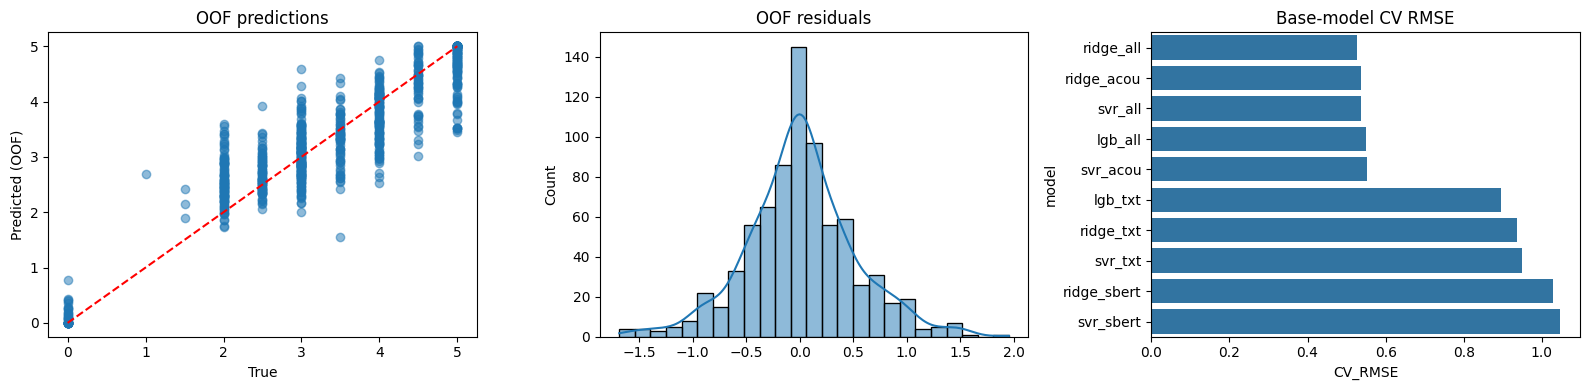

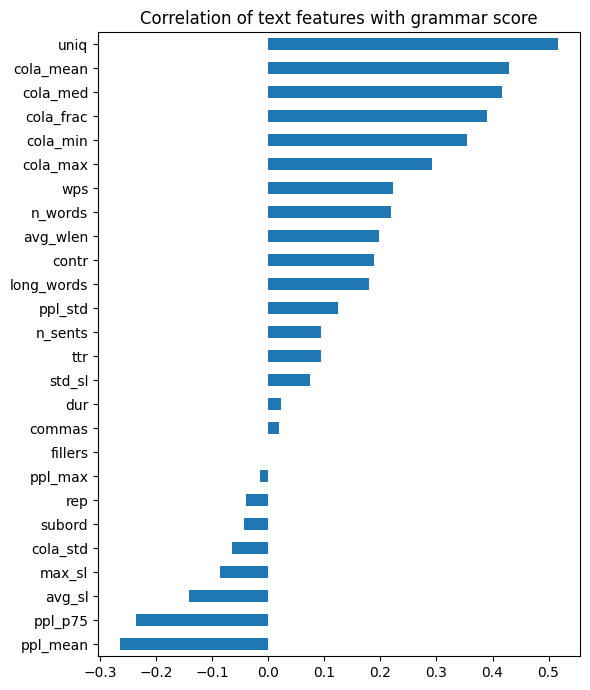

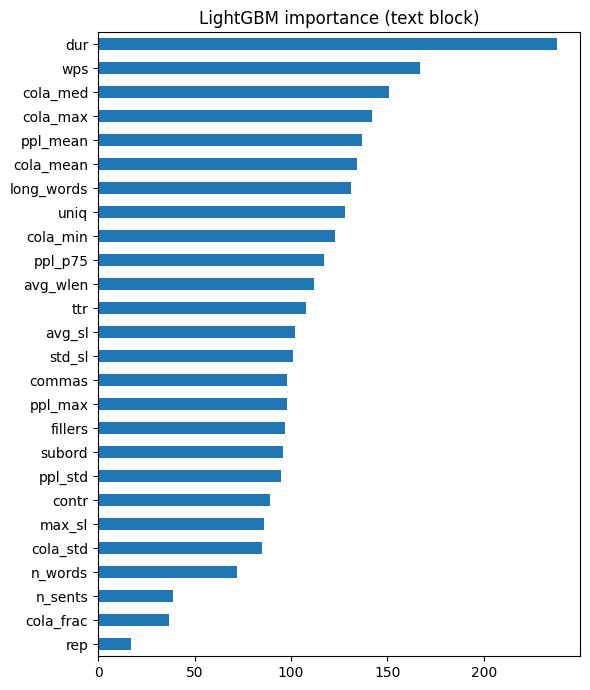

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].scatter(y, st_oof, alpha=.5); ax[0].plot([0,5],[0,5],'r--'); ax[0].set_xlabel('True'); ax[0].set_ylabel('Predicted (OOF)'); ax[0].set_title('OOF predictions')
sns.histplot(y - st_oof, bins=25, kde=True, ax=ax[1]); ax[1].set_title('OOF residuals')
sns.barplot(data=res, y='model', x='CV_RMSE', ax=ax[2]); ax[2].set_title('Base-model CV RMSE'); plt.tight_layout(); plt.show()

# Correlation of interpretable grammar features with the label
df_t = pd.DataFrame(TXT[:ntr], columns=TXT_NAMES); df_t['label'] = y
corr = df_t.corr()['label'].drop('label').sort_values()
plt.figure(figsize=(6, 7)); corr.plot.barh(); plt.title('Correlation of text features with grammar score'); plt.tight_layout(); plt.show()

# LightGBM feature importance on the text block
imp = pd.Series(final['lgb_txt'].feature_importances_, index=TXT_NAMES).sort_values()
plt.figure(figsize=(6, 7)); imp.plot.barh(); plt.title('LightGBM importance (text block)'); plt.tight_layout(); plt.show()

## 9. Test predictions and submission

In [14]:
te_P = np.column_stack([
    final[k].predict(blocks[base[k][1]][ntr:])
    for k in keys
])

test_pred = np.clip(meta.predict(te_P), 0, 5)

out = pd.DataFrame({
    sub.columns[0]: test[FILE_COL].values,
    sub.columns[1]: test_pred
})

out.to_csv('/kaggle/working/submission.csv', index=False)

print(out.head())
print(out.shape, '| pred range',
      round(test_pred.min(), 2),
      round(test_pred.max(), 2))

        filename     label
0  audio_128.wav  2.952507
1  audio_156.wav  4.099736
2   audio_19.wav  4.649838
3  audio_108.wav  1.926913
4  audio_206.wav  2.066594
(216, 2) | pred range 1.68 5.0


## 10. Report
**Problem.** Regress a 0-5 MOS grammar score from ~1 min speech clips (769 train / 216 test). Small data -> favour frozen pretrained encoders + regularised regressors over end-to-end fine-tuning (which overfits at this size).

**Preprocessing.** Resample to 16 kHz mono, trim silence; Whisper chunked transcription (30 s windows); sentence splitting of transcripts; feature standardisation inside each CV pipeline (no leakage).

**Pipeline.**
- *Text-grammar block:* length/fluency/syntax statistics, CoLA grammatical-acceptability stats, GPT-2 token loss (perplexity proxy).
- *Semantic block:* all-mpnet-base-v2 sentence embedding.
- *Acoustic block:* WavLM-base-plus layer-wise mean/std pooling (captures hesitation, prosody, proficiency).
- *Base learners:* RidgeCV, SVR (PCA for high-dim), LightGBM.
- *Ensemble:* non-negative linear stacking over 3x repeated 5-fold OOF predictions; output clipped to [0, 5].

**Evaluation.** RMSE (primary), Pearson r. The training RMSE (in-sample) and the cross-validated RMSE are printed in Section 7; CV RMSE is the reliable predictor of leaderboard performance. Diagnostics: OOF scatter, residual histogram, feature correlation/importance.

**Limitations / next steps.** Whisper cleans disfluencies and self-corrections, which matter for score 4-5 (use word-level timestamps for pause features); LanguageTool error counts or an LLM grammar-rating feature are strong additions; try WavLM-large / Whisper-encoder embeddings; light fine-tuning of DeBERTa-v3 on transcripts with CV; ordinal-aware loss.